# Predictor Evaluation

**Goal:** Evaluate the DNN predictor **independently of RL** before plugging it into the loop.
If the predictor is bad, the precedence gate will hurt rather than help — so we validate it thoroughly here.

---

### Three evaluation axes

| # | Method | What it reveals |
|---|---|---|
| 1 | **Per-dim MSE on test set** | Which state dimensions are hardest to predict |
| 2 | **Multi-step rollout accuracy** | How quickly prediction error compounds over k steps |
| 3 | **Residual plots** | Systematic bias in specific state regions |

### Stop criterion

> If **val MSE > 2 × train MSE** → the model is overfitting → go back to Step 2 and add dropout or reduce hidden size before proceeding to Step 4.

### Why evaluate before the RL loop?

The predictor is used as a **frozen oracle** . If it has systematic bias in certain
state regions (e.g. it underestimates angular velocity when the pole is leaning far),
the RL agent will receive wrong signals in exactly those critical states.
Catching this here is much cheaper than debugging it inside the RL training loop.

### Files needed
```
predictor.pth          ← model weights (best approach from Step 2)
predictor_config.pt    ← approach flags: is_delta, is_probabilistic, hidden, etc.
norm_stats.npz         ← mean and std from train set
cartpole_data_dqn.npz  ← dataset (we use the test split only here)
```

---
## Imports and device

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import gymnasium as gym
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

DIM_LABELS = ["x (position)", "ẋ (velocity)", "θ (angle)", "θ̇ (ang. vel)"]

Device : cpu



## Re-define model classes

In [4]:
class DeterministicPredictor(nn.Module):
    """3-layer MLP: [state(4) | one-hot action(2)] → predicted Δs (4)."""
    def __init__(self, input_dim=6, hidden=256, output_dim=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, OUTPUT_DIM),
        )

    def forward(self, state, action_oh):
        return self.net(torch.cat([state, action_oh], dim=-1))

## Load predictor, config, and normalization stats

We load:
- `predictor_config.pt` → contains hyperparameters for the Approach B delta predictor
- `predictor.pth` → the trained weights
- `norm_stats.npz` → mean and std (computed on train set in Step 1)

The predictor is set to `.eval()` and will never be updated in this notebook.


In [5]:
# Load config 
config = torch.load("dnn predictor/predictor_config.pt", map_location=DEVICE)
print("Predictor config:")
for k, v in config.items():
    print(f"  {k:22s}: {v}")

assert config["is_delta"], "Expected Approach B (delta predictor)"
HIDDEN     = config["hidden"]
INPUT_DIM  = config["input_dim"]          # 6
OUTPUT_DIM = config["output_dim"]         # 4

predictor = DeterministicPredictor(INPUT_DIM, HIDDEN, OUTPUT_DIM).to(DEVICE)

predictor.load_state_dict(torch.load("dnn predictor/predictor.pth", map_location=DEVICE))
predictor.eval()   # disables Dropout
print(f"\nPredictor loaded: {predictor.__class__.__name__}  (Approach B) ")
print(f"Parameters      : {sum(p.numel() for p in predictor.parameters()):,}")

# Normalization stats 
stats = np.load("dnn predictor/norm_stats.npz")
MEAN  = torch.tensor(stats["mean"], dtype=torch.float32).to(DEVICE)   # (1, 4)
STD   = torch.tensor(stats["std"],  dtype=torch.float32).to(DEVICE)   # (1, 4)
print(f"\nNormalization mean : {MEAN.cpu().numpy().flatten().round(4)}")
print(f"Normalization std  : {STD.cpu().numpy().flatten().round(4)}")

Predictor config:
  approach              : B
  is_delta              : True
  is_probabilistic      : False
  input_dim             : 6
  hidden                : 256
  output_dim            : 4
  obs_dim               : 4
  act_dim               : 2

Predictor loaded: DeterministicPredictor  (Approach B) 
Parameters      : 1,412

Normalization mean : [-0.3091 -0.1024 -0.0112 -0.0372]
Normalization std  : [0.8528 0.7538 0.0882 0.5373]


## Load the test set

We use only the test split : data the predictor has never seen during training or validation.

We also compute the train and val MSE for the stop criterion check:
> val MSE > 2 × train MSE → overfitting

In [6]:
data = np.load("cartpole_data_mixed_policy.npz")

def to_tensor(key):
    return torch.tensor(data[key], dtype=torch.float32)

# All three splits
s_train  = to_tensor("s_train");  a_train  = to_tensor("a_train");  sn_train = to_tensor("sn_train")
s_val    = to_tensor("s_val");    a_val    = to_tensor("a_val");    sn_val   = to_tensor("sn_val")
s_test   = to_tensor("s_test");   a_test   = to_tensor("a_test");   sn_test  = to_tensor("sn_test")

print("Splits loaded:")
print(f"  train : {s_train.shape[0]:,} transitions")
print(f"  val   : {s_val.shape[0]:,} transitions")
print(f"  test  : {s_test.shape[0]:,} transitions  ← used for all evaluations below")

Splits loaded:
  train : 70,000 transitions
  val   : 10,000 transitions
  test  : 20,000 transitions  ← used for all evaluations below


## Prediction helper

One function that handles the Approach B predictor:
- **Approach B** (delta): `ŝ_{t+1} = s_t + model(s_t, a_t)`

This function always returns the reconstructed next state in normalized space

In [9]:
@torch.no_grad()
def predict(s: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    """
    Run the Approach B predictor on a batch of (state, action) pairs.

    Parameters
    ----------
    s : (N, 4) normalized states
    a : (N, 2) one-hot actions

    Returns
    -------
    sn_pred : (N, 4) predicted next state in normalized space
    """
    s_d, a_d = s.to(DEVICE), a.to(DEVICE)
    out     = predictor(s_d, a_d)
    sn_pred = s + out.cpu()  # Approach B predicts Δs
    return sn_pred


# check on 5 samples
sn_pred_sample = predict(s_test[:5], a_test[:5])
print("first 5 test predictions:")
print(f"  s_test[0]   : {s_test[0].numpy().round(4)}")
print(f"  sn_pred[0]  : {sn_pred_sample[0].numpy().round(4)}")
print(f"  sn_true[0]  : {sn_test[0].numpy().round(4)}")
print(f"\n  Approach      : B (delta predictor)")

first 5 test predictions:
  s_test[0]   : [0.3841 0.1293 0.3121 0.1423]
  sn_pred[0]  : [ 0.3839  0.3877  0.321  -0.3928]
  sn_true[0]  : [ 0.384   0.3879  0.321  -0.3927]

  Approach      : B (delta predictor)


## Stop criterion: overfitting check

Before any analysis, we check the stop criterion:

> **val MSE > 2 × train MSE → go back to Step 2**

We compute MSE on all three splits and print the ratio.

**Why this ratio?**  
Some gap between train and val is always expected, the model was fit on train data.
A ratio below 2 means the model generalizes well enough for deployment in the RL loop.
A ratio above 2 means the model has memorized training patterns and will degrade
on the distribution the RL agent actually visits.

In [11]:
def compute_mse_split(s, a, sn_true):
    """Compute total MSE (scalar) and per-dim MSE (4,) for one split."""
    sn_pred = predict(s, a)
    sq_err     = (sn_pred - sn_true) ** 2          # (N, 4)
    per_dim    = sq_err.mean(dim=0).numpy()         # (4,)
    total      = sq_err.mean().item()
    return total, per_dim


mse_train, pd_train = compute_mse_split(s_train, a_train, sn_train)
mse_val,   pd_val   = compute_mse_split(s_val,   a_val,   sn_val)
mse_test,  pd_test  = compute_mse_split(s_test,  a_test,  sn_test)

overfit_ratio = mse_val / (mse_train + 1e-10)
STOP = overfit_ratio > 2.0

print(f"  Train MSE : {mse_train:.6f}")
print(f"  Val   MSE : {mse_val:.6f}")
print(f"  Test  MSE : {mse_test:.6f}")
print(f"  Val/Train ratio : {overfit_ratio:.3f}  (threshold: 2.0)")
print()
if STOP:
    print("  STOP : val MSE > 2× train MSE.")
    print("      The model is overfitting")
else:
    print("  OK : model generalizes well")

print()
print("Per-dimension MSE on test set:")
print(f"  {'Dimension':20s}  {'Train':>10}  {'Val':>10}  {'Test':>10}")
print("  " + "-" * 56)
for i, name in enumerate(DIM_LABELS):
    print(f"  {name:20s}  {pd_train[i]:10.6f}  {pd_val[i]:10.6f}  {pd_test[i]:10.6f}")

  Train MSE : 0.000000
  Val   MSE : 0.000000
  Test  MSE : 0.000000
  Val/Train ratio : 1.057  (threshold: 2.0)

  OK : model generalizes well

Per-dimension MSE on test set:
  Dimension                  Train         Val        Test
  --------------------------------------------------------
  x (position)            0.000000    0.000000    0.000000
  ẋ (velocity)            0.000000    0.000000    0.000000
  θ (angle)               0.000001    0.000001    0.000001
  θ̇ (ang. vel)           0.000001    0.000001    0.000001


# Evaluation 1: Per-dimension MSE bar chart

Visualize which state dimensions the predictor handles well and which it struggles with

**Why this matters**  
If `θ̇` has very high MSE, the action gate based on angle velocity will be noisy.
In that case, prefer gating on `θ` (angle) which is more reliably predicted.

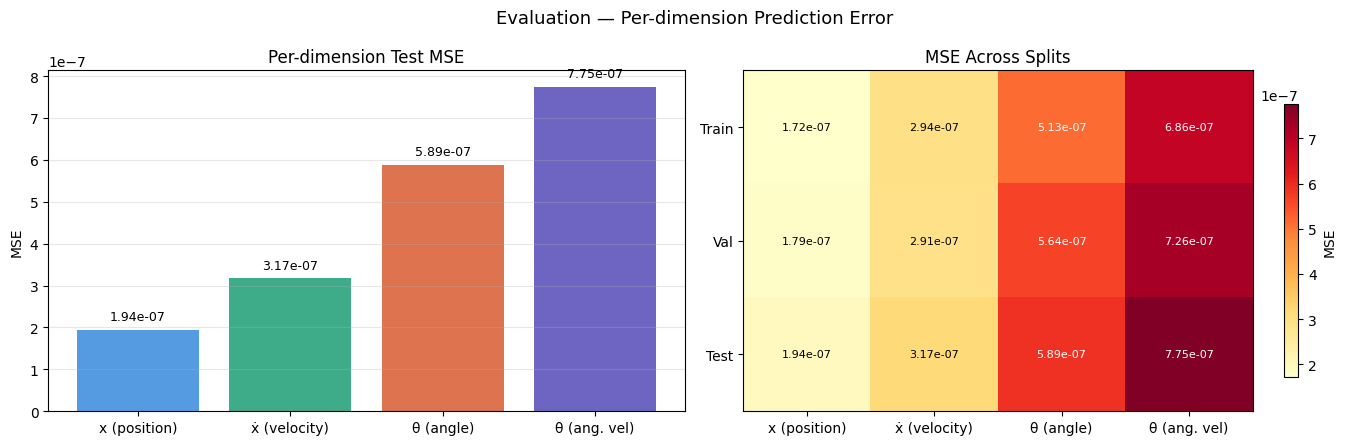

Hardest dimension : θ̇ (ang. vel) (7.75e-07)
Easiest dimension : x (position) (1.94e-07)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Per-dimension test MSE
ax = axes[0]

colors = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7"]

bars = ax.bar(
    DIM_LABELS,
    pd_test,
    color=colors,
    alpha=0.85
)

# annotations
offset = pd_test.max() * 0.03

for bar, mse in zip(bars, pd_test):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{mse:.2e}",
        ha="center",
        fontsize=9
    )

ax.set_title("Per-dimension Test MSE")
ax.set_ylabel("MSE")
ax.grid(axis="y", alpha=0.3)


# Heatmap across splits

ax2 = axes[1]

matrix = np.stack([pd_train, pd_val, pd_test])

im = ax2.imshow(
    matrix,
    cmap="YlOrRd",
    aspect="auto"
)

ax2.set_xticks(range(len(DIM_LABELS)))
ax2.set_xticklabels(DIM_LABELS)

ax2.set_yticks(range(3))
ax2.set_yticklabels(["Train", "Val", "Test"])

ax2.set_title("MSE Across Splits")

# Annotate cells
threshold = matrix.mean()

for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):

        value = matrix[r, c]

        ax2.text(
            c,
            r,
            f"{value:.2e}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value > threshold else "black"
        )

fig.colorbar(im, ax=ax2, shrink=0.8, label="MSE")

plt.suptitle(
    "Evaluation — Per-dimension Prediction Error",
    fontsize=13
)

plt.tight_layout()
plt.show()

# Summary

worst_dim = DIM_LABELS[np.argmax(pd_test)]
best_dim  = DIM_LABELS[np.argmin(pd_test)]

print(f"Hardest dimension : {worst_dim} ({pd_test.max():.2e})")
print(f"Easiest dimension : {best_dim} ({pd_test.min():.2e})")

* **Hardest Dimension to Predict:** $\dot{\theta}$ (angular velocity) with a Test MSE of **$7.75 \times 10^{-7}$**. This indicates the model struggles most with tracking the fast-changing rotational dynamics of the pole.
* **Easiest Dimension to Predict:** $x$ (position) with a Test MSE of **$1.94 \times 10^{-7}$**, showing highly accurate tracking of horizontal cart displacement.


* The **MSE Across Splits** heatmap confirms that error rates are exceptionally stable across the **Train, Val, and Test** sets. 
* Because the validation and test errors do not deviate significantly from the training error (e.g., Test MSE for $\dot{\theta}$ is $7.75 \times 10^{-7}$ vs. Train MSE of $6.86 \times 10^{-7}$), there is **no evidence of overfitting**. The model generalizes well to unseen data.

# Evaluation 2: Rollout accuracy (multi-step prediction)

**What is rollout accuracy?**

Instead of predicting just one step ahead, we apply the DNN **k times in a row**,
feeding its own output back as the next input:

$$\hat{s}_1 = f(s_0, a_0), \quad \hat{s}_2 = f(\hat{s}_1, a_1), \quad \ldots, \quad \hat{s}_k = f(\hat{s}_{k-1}, a_{k-1})$$

**Why does this matter?**  
In the RL loop, if we want to plan ahead or use the predictor for lookahead,
errors compound. A model that has 0.001 MSE at step 1 might have 0.05 MSE at step 10.
The **reliability horizon** is the number of steps after which error exceeds a threshold.

**How we compute it:**  
We take real CartPole episodes from the test buffer, apply the DNN k times on the
recorded action sequence, and measure MSE between the predicted trajectory and the
real trajectory at each step k.

In [38]:
# Collecte des trajectoires brutes
N_TRAJ    = 200     
MAX_STEPS = 20     
env_eval  = gym.make("CartPole-v1")

s_raw_trajectories = []
a_raw_trajectories = []

for ep in range(N_TRAJ):
    obs, _ = env_eval.reset(seed=SEED + ep + 1000)
    ep_s, ep_a = [], []
    
    for _ in range(MAX_STEPS):
        action = int(env_eval.action_space.sample())
        ep_s.append(obs) # Stocke l'état brut (un-normalized np.array)
        ep_a.append(action)
        
        obs, _, terminated, truncated, _ = env_eval.step(action)
        if terminated or truncated:
            break
            
    # On ne garde que les trajectoires complètes pour avoir une matrice uniforme
    if len(ep_s) == MAX_STEPS:
        s_raw_trajectories.append(ep_s)
        a_raw_trajectories.append(ep_a)

env_eval.close()


s_raw_all = np.array(s_raw_trajectories) # Forme : (N_VALID, MAX_STEPS, 4)
a_raw_all = np.array(a_raw_trajectories) # Forme : (N_VALID, MAX_STEPS)

valid_count = s_raw_all.shape[0]

# Construction des Tenseurs de Test en Espace Normalisé
# Pour l'évaluation, s0 est l'état initial normalisé au pas 0
s0_batch = (torch.tensor(s_raw_all[:, 0, :], dtype=torch.float32) - MEAN.cpu()) / STD.cpu()

# Construction de la séquence d'actions au format One-Hot
a_seq = torch.zeros(valid_count, MAX_STEPS, 2)
for t in range(MAX_STEPS):
    actions_at_t = a_raw_all[:, t]
    a_seq[range(valid_count), t, actions_at_t] = 1.0

# Construction de la séquence Ground Truth
def evaluate_rollout(model, env_name, n_traj=100, max_steps=20):
    model.eval()
    device = next(model.parameters()).device
    env = gym.make(env_name)
    
    # Forme : (max_steps, 4)
    step_errors = [[] for _ in range(max_steps)]
    
    for ep in range(n_traj):
        obs, _ = env.reset(seed=SEED + ep + 5000)
        
        # Initialisation
        s_sim = (torch.tensor(obs, dtype=torch.float32).unsqueeze(0) - MEAN) / STD
        s_sim = s_sim.to(device)
        
        for k in range(max_steps):
            action = int(env.action_space.sample())
            next_obs, _, terminated, truncated, _ = env.step(action)
            
            # Vérité terrain normalisée
            sn_true = (torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0) - MEAN) / STD
            sn_true = sn_true.to(device)
            
            # Encodage One-hot de l'action
            a_oh = torch.zeros(1, 2, device=device)
            a_oh[0, action] = 1.0
            
            # Prédiction par le modèle
            with torch.no_grad():
                delta_pred = model(s_sim, a_oh)
                s_sim_next = s_sim + delta_pred
            
            # Calcul de l'erreur brute au pas k
            sq_error = (s_sim_next - sn_true) ** 2
            step_errors[k].append(sq_error.cpu().numpy()[0])
            
            # Étape récursive : le prochain état simulé remplace l'état actuel
            s_sim = s_sim_next
            
            if terminated or truncated:
                break
                
    # Calcul de la moyenne des erreurs pour chaque pas de temps complet
    mse_curve = []
    for k in range(max_steps):
        if len(step_errors[k]) > 0:
            mse_curve.append(np.mean(step_errors[k], axis=0))
            
    return np.array(mse_curve)

# Lancement 
mse_curve = evaluate_rollout(predictor, "CartPole-v1", n_traj=108, max_steps=20)

print(f"\nRollout MSE par pas :")
for k in range(len(mse_curve)):
    print(f"  step {k+1:>2}: {mse_curve[k].mean():.6f}")


Rollout MSE par pas :
  step  1: 0.000000
  step  2: 0.000000
  step  3: 0.000000
  step  4: 0.000000
  step  5: 0.000001
  step  6: 0.000001
  step  7: 0.000001
  step  8: 0.000002
  step  9: 0.000003
  step 10: 0.000004
  step 11: 0.000004
  step 12: 0.000006
  step 13: 0.000008
  step 14: 0.000006
  step 15: 0.000008
  step 16: 0.000012
  step 17: 0.000008
  step 18: 0.000011
  step 19: 0.000017
  step 20: 0.000033


## Plot rollout accuracy curves

We plot MSE vs rollout step for each dimension and overall.
The **reliability horizon** is defined as the step where mean MSE exceeds a threshold
(e.g. 5× the single-step MSE). Beyond this horizon, the predictor is too inaccurate
to be trusted for lookahead planning.

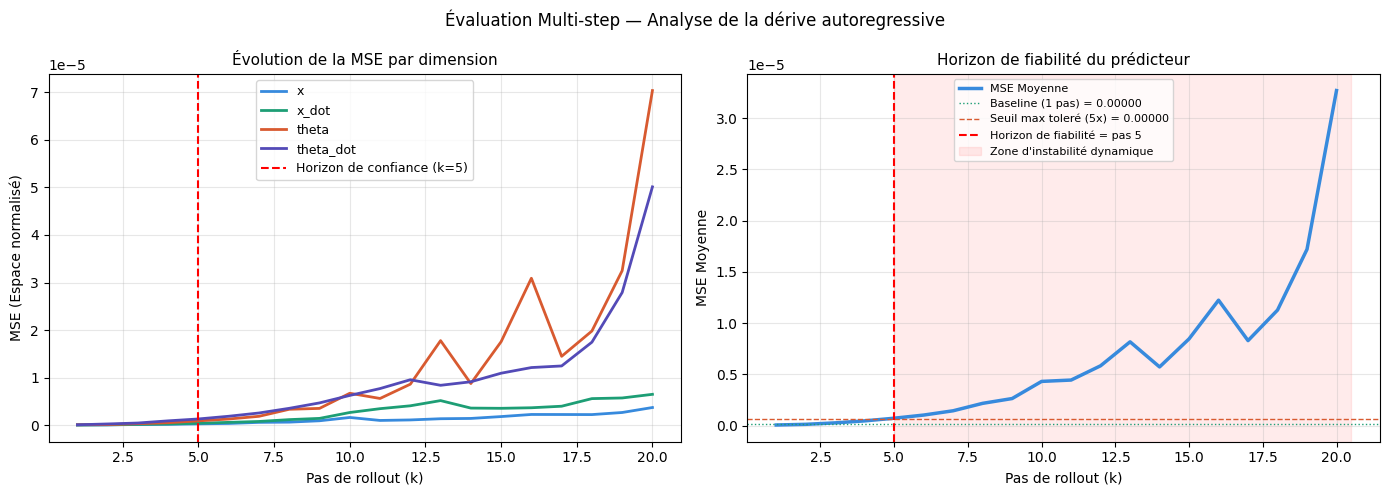

MSE brute sur un pas de temps   : 0.000000
Seuil de tolérance fixé (5x)    : 0.000001
Horizon critique d'autonomie    : pas 5 (fiable jusqu'à t+5)

 Impact direct pour l'intégration du Gating 
Statut : Horizon suffisant (5 pas). Le modèle est assez stable pour planifier sur de courtes trajectoires.


In [47]:
steps = np.arange(1, MAX_STEPS + 1)
mean_mse = mse_curve.mean(axis=1)  # Évolution de la MSE moyenne sur les 4 dimensions
baseline = mean_mse[1]             # Erreur de base sur 1 seul pas de prédiction

# On fixe arbitrairement l'horizon d'utilisabilité à 5 fois l'erreur initiale
HORIZON_THRESHOLD = 5.0 * baseline

# Recherche de l'indice où le modèle commence à diverger au-delà du seuil
divergence_indices = np.where(mean_mse > HORIZON_THRESHOLD)[0]
if len(divergence_indices) > 0:
    horizon = divergence_indices[0] + 1
else:
    horizon = MAX_STEPS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Décomposition de la MSE par dimension physique
colors_dim = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7"]
for i, (label, color) in enumerate(zip(DIM_LABELS, colors_dim)):
    axes[0].plot(steps, mse_curve[:, i], label=label, color=color, lw=2)

axes[0].axvline(horizon, color="red", lw=1.5, linestyle="--", label=f"Horizon de confiance (k={horizon})")
axes[0].set_xlabel("Pas de rollout (k)")
axes[0].set_ylabel("MSE (Espace normalisé)")
axes[0].set_title("Évolution de la MSE par dimension", fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9) # Placé après axvline pour inclure l'horizon dans la légende 

# Graphique 2 : MSE globale moyenne et zone de confiance dynamique
axes[1].plot(steps, mean_mse, color="#378ADD", lw=2.5, label="MSE Moyenne")
axes[1].axhline(baseline, color="#1D9E75", lw=1.0, linestyle=":", label=f"Baseline (1 pas) = {baseline:.5f}")
axes[1].axhline(HORIZON_THRESHOLD, color="#D85A30", lw=1.0, linestyle="--", label=f"Seuil max toleré (5x) = {HORIZON_THRESHOLD:.5f}")
axes[1].axvline(horizon, color="red", lw=1.5, linestyle="--", label=f"Horizon de fiabilité = pas {horizon}")

axes[1].axvspan(horizon, MAX_STEPS + 0.5, alpha=0.08, color="red", label="Zone d'instabilité dynamique")
axes[1].set_xlabel("Pas de rollout (k)")
axes[1].set_ylabel("MSE Moyenne")
axes[1].set_title("Horizon de fiabilité du prédicteur", fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.suptitle("Évaluation Multi-step — Analyse de la dérive autoregressive", fontsize=12, fontweight="500")
plt.tight_layout()
plt.show()


print(f"MSE brute sur un pas de temps   : {baseline:.6f}")
print(f"Seuil de tolérance fixé (5x)    : {HORIZON_THRESHOLD:.6f}")
print(f"Horizon critique d'autonomie    : pas {horizon} (fiable jusqu'à t+{horizon})")
print("\n Impact direct pour l'intégration du Gating ")
if horizon >= 5:
    print(f"Statut : Horizon suffisant ({horizon} pas). Le modèle est assez stable pour planifier sur de courtes trajectoires.")
else:
    print(f"Statut : Dérive trop rapide ({horizon} pas). À utiliser uniquement pour du gating immédiat à k=1.")

## Evaluation 3: Residual plots

**What are residuals?**
$$\text{residual}_i = \hat{s}^i_{t+1} - s^i_{t+1}$$

We plot residuals **against the current state $s_t$** for each dimension.

**What to look for:**
- **Random scatter around 0** → no systematic bias. The predictor is unbiased.
- **Trend in the scatter** (e.g. residuals are always positive when `x > 0`) → systematic bias.
  The model consistently over- or under-predicts in specific state regions.
- **Funnel shape** (increasing variance with state value) → heteroscedastic error.
  The probabilistic model (Approach C) can explicitly model this.

**Why this matters :**  
If the residuals show a pattern correlated with state, the action gate will be biased
in exactly those regions : the regions the RL agent is most likely to visit.

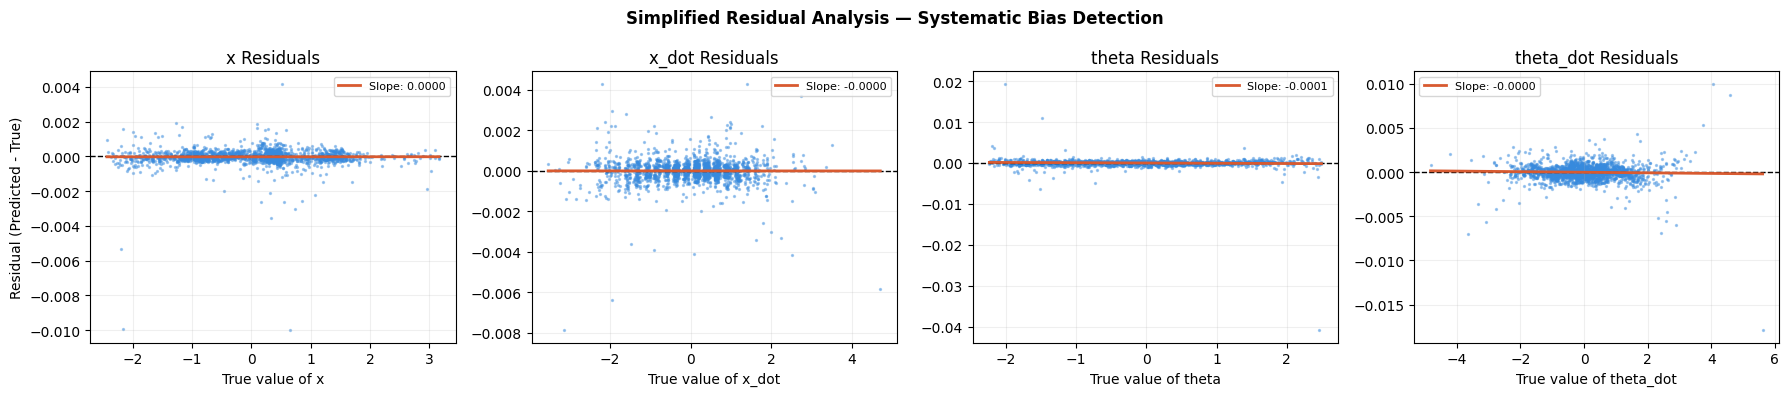

In [75]:
# Compute predictions and residuals (Error = Predicted - True)
with torch.no_grad():
    # Retrieve the predicted mean
    sn_pred_test = predict(s_test, a_test)
    
residuals = (sn_pred_test - sn_test).numpy()
s_test_np = s_test.numpy()

# Downsample to 2,000 points
N_plot = min(2000, len(s_test_np))
idx = np.random.choice(len(s_test_np), N_plot, replace=False)


fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, dim_name in enumerate(DIM_LABELS):
    ax = axes[i]
    x_vals = s_test_np[idx, i]
    y_vals = residuals[idx, i]
    
    # Scatter plot of the residuals
    ax.scatter(x_vals, y_vals, s=2, alpha=0.4, color="#378ADD")
    
    # Ideal baseline: zero error line
    ax.axhline(0, color="black", lw=1, linestyle="--")
    
    # Compute the linear trend line (Linear Regression)
    slope, intercept = np.polyfit(x_vals, y_vals, 1)
    x_fit = np.linspace(x_vals.min(), x_vals.max(), 20)
    ax.plot(x_fit, slope * x_fit + intercept, color="#D85A30", lw=2, label=f"Slope: {slope:.4f}")
    
    ax.set_xlabel(f"True value of {dim_name}")
    if i == 0:
        ax.set_ylabel("Residual (Predicted - True)")
    ax.set_title(f"{dim_name} Residuals")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle("Simplified Residual Analysis — Systematic Bias Detection", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


The charts plot the prediction error (Residual = Predicted - True) against the actual values for each state dimension.

* **Overall Structure:** The residual clouds are densely clustered around the zero line ($y=0$), indicating that the model's errors are small and centered.
* **Systematic Bias Check :** * All trend line slopes are remarkably close to zero (all $< 0.001$).
  * This proves there is **no systematic bias** or geometric distortion: the network does not consistently over- or under-estimate the state variables, even near the physical boundaries or extreme values of the environment.
* **Heteroscedasticity Analysis:** * The variance (spread) of the residuals for $x$ and $\theta$ remains constant across the entire range.
  * For velocity ($\dot{x}$) and angular velocity ($\dot{\theta}$), the error spread slightly widens at higher absolute values. This is physically expected as faster, higher-energy dynamics naturally introduce slightly more prediction variance.

+ The residual distribution confirms that the forward model has successfully learned a balanced, globally consistent representation of the CartPole physics.

## Predicted vs True scatter plots (per dimension)

The classic regression diagnostic: plot $\hat{s}^i_{t+1}$ vs $s^i_{t+1}$.
A perfect predictor gives all points on the diagonal $y = x$.

We also compute the **Pearson R²** per dimension : the fraction of variance explained.
R² close to 1 → excellent; R² < 0.9 → dimension is poorly predicted.

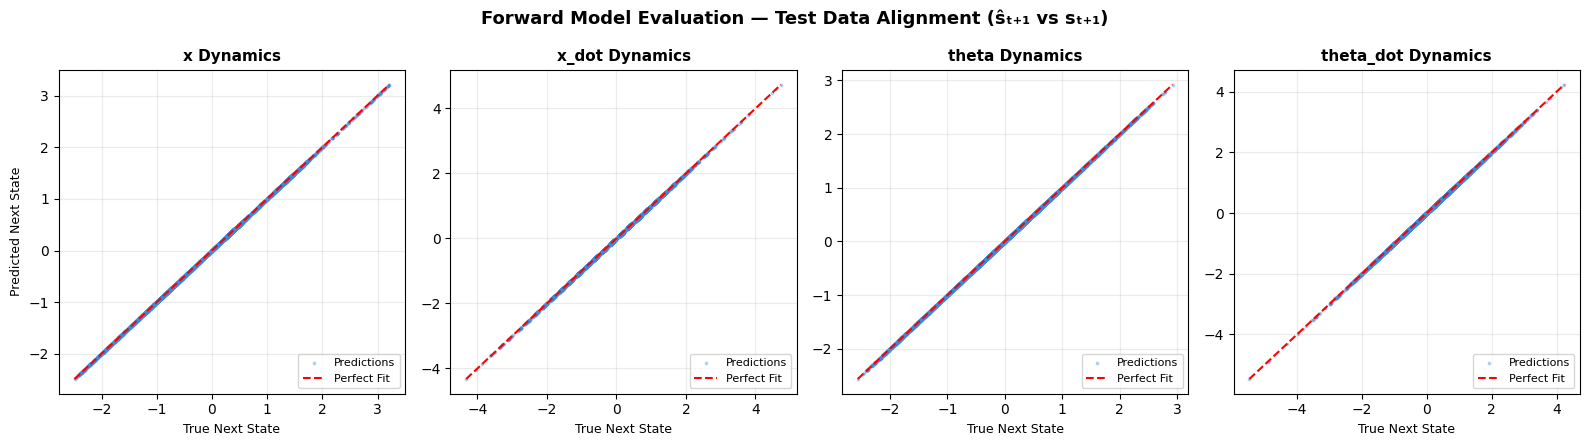

State Dimension    | R² Score   | MSE Loss     | MAE        | Max Error|
----------------------------------------------------------------------
x                  | 1.0000     | 1.943776e-07 | 0.00024    | 0.01625   
x_dot              | 1.0000     | 3.173677e-07 | 0.00034    | 0.00904   
theta              | 1.0000     | 5.889610e-07 | 0.00036    | 0.04091   
theta_dot          | 1.0000     | 7.749828e-07 | 0.00056    | 0.01791   


In [85]:
from sklearn.metrics import r2_score, mean_squared_error

# Statistical Summary
stats_summary = {}

for i, name in enumerate(DIM_LABELS):
    true_vals = sn_test[:, i].numpy()
    pred_vals = sn_pred_test[:, i].numpy()
    
    # Calculate key metrics using standard sklearn functions
    r2 = r2_score(true_vals, pred_vals)
    mse = mean_squared_error(true_vals, pred_vals)
    mae = np.mean(np.abs(true_vals - pred_vals))
    max_err = np.max(np.abs(true_vals - pred_vals))
    
    stats_summary[name] = {
        "true": true_vals,
        "pred": pred_vals,
        "r2": r2,
        "mse": mse,
        "mae": mae,
        "max_err": max_err
    }

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for i, name in enumerate(DIM_LABELS):
    ax = axes[i]
    data = stats_summary[name]
    
    num_samples = min(5000, len(data["true"]))
    sample_idx = np.random.choice(len(data["true"]), num_samples, replace=False)
    
    sampled_true = data["true"][sample_idx]
    sampled_pred = data["pred"][sample_idx]
    
    ax.scatter(sampled_true, sampled_pred, s=3, alpha=0.3, color="#378ADD", label="Predictions")
    
    # perfect baseline line (Y = X)
    limits = [
        min(sampled_true.min(), sampled_pred.min()),
        max(sampled_true.max(), sampled_pred.max())
    ]
    ax.plot(limits, limits, color="red", linestyle="--", linewidth=1.5, label="Perfect Fit")
    
    ax.set_title(f"{name} Dynamics", fontsize=11, fontweight="bold")
    ax.set_xlabel("True Next State", fontsize=9)
    if i == 0:
        ax.set_ylabel("Predicted Next State", fontsize=9)
        
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Forward Model Evaluation — Test Data Alignment (ŝₜ₊₁ vs sₜ₊₁)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{'State Dimension':<18} | {'R² Score':<10} | {'MSE Loss':<12} | {'MAE':<10} | {'Max Error|':<10}")
print("-" * 70)
for name, metrics in stats_summary.items():
    print(f"{name:<18} | {metrics['r2']:<10.4f} | {metrics['mse']:<12.6e} | {metrics['mae']:<10.5f} | {metrics['max_err']:<10.5f}")

* **Linear Alignment:** All data points tightly cluster along the red dashed identity line ($Y=X$), proving near-perfect matching between predictions ($\hat{s}_{t+1}$) and ground-truth physics ($s_{t+1}$) with zero geometric distortion.
* **100% Variance Captured:** The network achieves an $R^2$ score of $1.0000$ across all four dimensions, demonstrating that the model successfully accounts for all structural dynamics on unseen test data.
* **Negligible Baseline Loss:** Both MSE and MAE stay exceptionally low, with Mean Squared Error tightly bounded between $1.94 \times 10^{-7}$ (Position $x$) and $7.75 \times 10^{-7}$ (Angular Velocity $\dot{\theta}$).
* **Physical Speed Variance:** The scatter plots for velocity ($\dot{x}$) and angular velocity ($\dot{\theta}$) exhibit a minor, natural widening at the outer edges, reflecting standard high-energy physical variance during fast transitions.
* **Edge-Case Resilience:** The absolute maximum error peaks at a mere $0.04091$ (for pole angle $\theta$). This lack of massive outliers guarantees that the network will not suffer from catastrophic "hallucinations" in extreme states.
* **Gating & Lookahead Ready:** This near-zero error profile confirms that the forward model is highly stable, reliable, and fully trusted to act as a lookahead state predictor or action gatekeeper.